# Finite elements with sparse matrices as values: a conduction tree by topology optimization

A square plate generates heat uniformly and may only shed it through a short heat sink in the middle
of its left edge. Given a limited amount of a good conductor, where should it go? This is the
*volume-to-point* heat conduction problem [Bejan 1997], and topology optimization answers it with a branching
tree of conductor.

On a triangulation with $n_e$ elements and a design density $\rho_e \in [0, 1]$ per element,

$$
\min_{\rho}\; c(\rho) = f^\top T \quad \text{s.t.} \quad K(\rho)\, T = f,\qquad \sum_e a_e \tilde\rho_e \le V,\qquad 0 \le \rho \le 1,
$$

where $K(\rho) = \sum_e k(\tilde\rho_e) K_e$ is the assembled conductance matrix, $\tilde\rho = H \rho$ a
filtered density and $k(\tilde\rho) = k_{\min} + (1-k_{\min})\tilde\rho^{\,3}$ the SIMP interpolation.

The notebook is about what `scaly.SparseMatrix` lets one write when patterns are fixed at build
time and values are expressions:

| Scaly feature | Where |
| --- | --- |
| `from_coo` summing repeated coordinates, `+` (pattern union), `*` (intersection), `@` between two sparse matrices, `tril`, `with_pattern`, `position` | the tour on two triangles |
| `from_coo` assembly of 16 200 element triplets, restriction $R K R^\top$ by sparse–sparse products | the conductance matrix |
| `sc.S` in a signature: a sparse matrix passed between two `Function`s, and a call refused for the wrong pattern | `conductance` and `temperature` |
| `linalg.analyze`, `SparseLDL(ordering=...)`: fill-in and elimination trees of natural, reverse Cuthill–McKee and minimum-degree orderings | orderings |
| reverse mode through `SparseLDL.solve`, the assembly and a constant sparse filter `H @ rho` | the adjoint gradient, and the optimization |

The optimizer is the optimality-criteria update of Sigmund's 99-line code [Sigmund 2001], driven from Python; every
compliance and gradient evaluation is one call of a generated C function.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.spatial import cKDTree

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
np.set_printoptions(precision=3, suppress=True, linewidth=110)
GENERATED = Path.cwd().parent / "generated" / "sparse_fem_topology"

## The linear triangle

On a triangle with vertices $p_1, p_2, p_3$ and area $a_e$, the hat functions have constant
gradients $\nabla\varphi_i = \frac{1}{2a_e}\,(y_j - y_k,\; x_k - x_j)$ for $(i, j, k)$ a cyclic
permutation, so the element conductance matrix is $K_e = a_e\,[\nabla\varphi_i\cdot\nabla\varphi_j]_{ij}$,
a $3\times 3$ matrix with zero row sums. A uniform source $f \equiv 1$ contributes $a_e/3$ to each
vertex. All of this is NumPy: only the conductivities $k_e$ will be symbolic.

In [2]:
def p1_element(p):
  # (3, 2) vertices -> (K_e, area)
  b = np.array([[p[1, 1] - p[2, 1], p[2, 1] - p[0, 1], p[0, 1] - p[1, 1]], [p[2, 0] - p[1, 0], p[0, 0] - p[2, 0], p[1, 0] - p[0, 0]]])
  area = 0.5 * abs(np.linalg.det(np.c_[np.ones(3), p]))
  return b.T @ b / (4 * area), area


def triplets(tris):
  # Row and column of the 9 entries of every element matrix, element by element.
  return np.repeat(tris, 3, axis=1).ravel(), np.tile(tris, (1, 3)).ravel()

## A tour of the sparse algebra on two triangles

Two triangles on the unit square, nodes 0–3 at its corners, share the diagonal 0–3. Their $2 \times 9$
element entries land on a $4\times 4$ matrix; `from_coo` sums the repeated coordinates (the shared
diagonal) when the graph is built, so the pattern has 14 stored entries, not 18: nodes 1 and 2
share no element. Then, all at build time as far as the patterns are concerned:

- `K + C` adds a *heat pipe* joining nodes 1 and 2: the pattern is the union, 16 entries.
- `K * eye`, with `eye` the identity, keeps the intersection of the patterns: the diagonal of $K$ as
  a sparse matrix.
- `R @ K @ R.T` with a constant selection $R$ removes node 0 (held at temperature zero): the pattern
  of a sparse–sparse product is worked out symbolically, the values are gathers, products and
  segment sums.
- `tril()` keeps the lower triangle, which is all `SparseLDL` reads.
- `eye.with_pattern(K)` puts the identity on $K$'s pattern, padding with zeros: two matrices that must
  share one pattern (a loop carry, a `Function` signature) can be made to.

A `Function` returns each as `sc.S(name, ...)`, whose pattern is whatever the body produces; a
numerical call returns SciPy CSC matrices.

In [3]:
xy2 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
tri2 = np.array([[0, 1, 3], [0, 3, 2]])
ke2 = np.stack([p1_element(xy2[t])[0] for t in tri2])
rows2, cols2 = triplets(tri2)
select_free = sc.SparseMatrix.from_scipy(sparse.csr_array(np.eye(4)[1:]))  # rows 1, 2, 3 of the identity


@sc.function(2, (), output=sc.G(*(sc.S(name, ...) for name in ("K", "K_pipe", "K_diag", "K_free", "K_lower", "I_on_K"))))
def tour(k, pipe):
  K = sc.SparseMatrix.from_coo(rows2, cols2, sc.gather(k, np.repeat([0, 1], 9)) * sc.const(ke2.ravel()), (4, 4))
  C = sc.SparseMatrix.from_coo([1, 2, 1, 2], [1, 2, 2, 1], pipe * sc.const([1.0, 1.0, -1.0, -1.0]), (4, 4))
  eye = sc.SparseMatrix.identity(4)
  return K, K + C, K * eye, select_free @ K @ select_free.T, K.tril(), eye.with_pattern(K)


outputs = tour(np.array([1.0, 2.0]), np.array(0.5))
for name, m in zip(("K", "K + C", "K * eye", "R K R^T", "tril(K)", "eye.with_pattern(K)"), outputs):
  print(f"{name}: {m.shape[0]}x{m.shape[1]}, {m.nnz} stored\n{m.toarray()}\n")

K: 4x4, 14 stored
[[ 1.5 -0.5 -1.   0. ]
 [-0.5  1.   0.  -0.5]
 [-1.   0.   2.  -1. ]
 [ 0.  -0.5 -1.   1.5]]

K + C: 4x4, 16 stored
[[ 1.5 -0.5 -1.   0. ]
 [-0.5  1.5 -0.5 -0.5]
 [-1.  -0.5  2.5 -1. ]
 [ 0.  -0.5 -1.   1.5]]

K * eye: 4x4, 4 stored
[[1.5 0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  2.  0. ]
 [0.  0.  0.  1.5]]

R K R^T: 3x3, 7 stored
[[ 1.   0.  -0.5]
 [ 0.   2.  -1. ]
 [-0.5 -1.   1.5]]

tril(K): 4x4, 9 stored
[[ 1.5  0.   0.   0. ]
 [-0.5  1.   0.   0. ]
 [-1.   0.   2.   0. ]
 [ 0.  -0.5 -1.   1.5]]

eye.with_pattern(K): 4x4, 14 stored
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]



The stored zeros of `eye.with_pattern(K)` are explicit: they are entries of the pattern, and a SciPy
matrix passed back into a `Function` declaring that pattern must carry them too.
`K.position(row, col)` says where an entry sits in the values vector, the handle for reading or
overwriting single entries of a symbolic matrix:

In [4]:
K_sym = sc.SparseMatrix.from_coo(rows2, cols2, sc.sym("v", 18), (4, 4))
print("entry (3, 0) is values[%d]; entry (2, 1) is %s" % (K_sym.position(3, 0), K_sym.position(2, 1)))
print("column pointers", K_sym.indptr, "\nrow indices    ", K_sym.indices)

entry (3, 0) is values[3]; entry (2, 1) is None
column pointers [ 0  4  7 10 14] 
row indices     [0 1 2 3 0 1 3 0 2 3 0 1 2 3]


## The plate

An $n\times n$ grid of squares, each cut into two triangles, on the unit square. The heat sink holds
the temperature at zero on the nodes of the left edge within $0.1$ of mid-height; every other edge
is insulated (a natural boundary condition, so nothing to do).

In [5]:
N_CELLS = 30
H_MESH = 1.0 / N_CELLS
NX = N_CELLS + 1
NN = NX * NX
XY = np.array([(j * H_MESH, i * H_MESH) for i in range(NX) for j in range(NX)])
node = np.arange(NN).reshape(NX, NX)
TRIS = np.concatenate([np.stack([node[:-1, :-1], node[:-1, 1:], node[1:, 1:]], -1).reshape(-1, 3), np.stack([node[:-1, :-1], node[1:, 1:], node[1:, :-1]], -1).reshape(-1, 3)])
NE = len(TRIS)
KE, AREA = map(np.array, zip(*(p1_element(XY[t]) for t in TRIS)))
ROWS, COLS = triplets(TRIS)
ELEMENT = np.repeat(np.arange(NE), 9)
F = np.bincount(TRIS.ravel(), np.repeat(AREA / 3, 3), NN)

SINK = node[np.abs(np.arange(NX) * H_MESH - 0.5) <= 0.1 + 1e-12, 0]
FREE = np.setdiff1d(np.arange(NN), SINK)
F_FREE = F[FREE]
R = sc.SparseMatrix.from_scipy(sparse.csr_array((np.ones(FREE.size), (np.arange(FREE.size), FREE)), shape=(FREE.size, NN)))
print(f"{NE} triangles, {NN} nodes, {SINK.size} of them in the sink, {FREE.size} unknowns, {ROWS.size} element triplets")

1800 triangles, 961 nodes, 7 of them in the sink, 954 unknowns, 16200 element triplets


## Assembly and restriction as sparse expressions

`assemble` scales each element's nine constant entries by its conductivity (one `gather`) and hands
the 16 200 triplets to `from_coo`. The restriction to the free nodes is $R K R^\top$, two sparse
products whose patterns are computed once, and `tril()` keeps the half that the factorization reads.
Both steps are cheap to build: the work is in NumPy on the patterns, and the values become a
handful of gathers and segment sums.

In [6]:
def assemble(k):
  return sc.SparseMatrix.from_coo(ROWS, COLS, sc.gather(k, ELEMENT) * sc.const(KE.reshape(-1)), (NN, NN))


k_sym = sc.sym("k", NE)
start = time.perf_counter()
K_full = assemble(k_sym)
K_free = (R @ K_full @ R.T).tril()
print(f"built in {1e3 * (time.perf_counter() - start):.1f} ms: {ROWS.size} triplets -> K with {K_full.nnz} entries -> R K R^T lower triangle with {K_free.nnz}")

built in 2.4 ms: 16200 triplets -> K with 6481 entries -> R K R^T lower triangle with 3692


## A sparse matrix between two `Function`s

`conductance` returns the restricted matrix as `sc.S("K", ...)`, and `temperature` declares its input
with exactly that pattern, `sc.S(K_PATTERN)`. Numerically the matrix travels as a SciPy CSC
matrix; symbolically (below, inside `compliance`) as a `SparseMatrix`, and the C interface is just
its values vector. The two agree with SciPy's own assembly and `spsolve`.

In [7]:
@sc.function(NE, output=sc.S("K", ...))
def conductance(k):
  return (R @ assemble(k) @ R.T).tril()


K_PATTERN = conductance.output_sparsities[0]


@sc.function(sc.S(K_PATTERN))
def temperature(K):
  fact = linalg.SparseLDL(K, name="plate")
  return R.T @ fact.solve(sc.const(F_FREE))


k0 = np.random.default_rng(0).uniform(0.2, 1.0, NE)
K_num = conductance(k0)
T_num = temperature(K_num)

K_scipy = sparse.csc_array(sparse.coo_array((k0[ELEMENT] * KE.reshape(-1), (ROWS, COLS)), shape=(NN, NN)))[FREE][:, FREE]
T_scipy = np.zeros(NN)
T_scipy[FREE] = sparse.linalg.spsolve(K_scipy, F_FREE)
print(type(K_num).__name__, K_num.shape, K_num.nnz, "stored")
print(f"|K - tril(K_scipy)|_max = {abs(K_num - sparse.tril(K_scipy)).max():.1e},  |T - T_scipy|_max = {np.abs(T_num - T_scipy).max():.1e}")

csc_array (954, 954) 3692 stored
|K - tril(K_scipy)|_max = 8.9e-16,  |T - T_scipy|_max = 4.0e-14


The declared pattern is part of `temperature`'s signature. SciPy's full symmetric matrix has the
same values but both triangles, so the call is refused rather than silently misread:

In [8]:
try:
  temperature(K_scipy)
except (ValueError, TypeError) as error:
  print(type(error).__name__ + ":", error)

ValueError: temperature.numerical_call: 'K' has a different sparsity pattern than declared: 6430 stored entries, expected 3692; column 1 stores rows [0, 1, 2, 32, 33], expected [1, 2, 32, 33]


## Orderings, fill-in and elimination trees

`SparseLDL` factors $P K P^\top = L D L^\top$ with the permutation $P$ chosen when the graph is
built. `linalg.analyze` exposes that analysis: the pattern of $L$ (its *fill* is every entry of $L$
not already in $K$), the elimination tree and the work. `ordering="auto"`, the default, keeps the
cheapest of the three:

- natural (row-by-row node numbering): a band of half-width $n$, filled completely;
- reverse Cuthill–McKee: a tighter profile, still a band;
- minimum degree: nested-dissection-like separators, much less fill, and an elimination tree that
  is bushy rather than a chain, which is also what parallel factorizations exploit.

In [9]:
rows_k, cols_k = sc.SparseMatrix.from_scipy(K_num).coordinates()
analyses = {m: linalg.analyze(K_num.shape, rows_k, cols_k, m) for m in ("natural", "rcm", "mmd")}
print(f"{'ordering':9s} {'nnz(L)':>8s} {'fill':>8s} {'multiply-adds':>14s} {'tree height':>12s}")
for m, s in analyses.items():
  st = s.stats()
  print(f"{m:9s} {st['nnz_l']:8d} {st['fill']:8d} {st['update_lanes']:14d} {st['height']:12d}")
print("ordering='auto' chooses:", linalg.SparseLDL(conductance(sc.sym("k", NE)), name="probe").symbolic.method)

ordering    nnz(L)     fill  multiply-adds  tree height
natural      29266    26528         473258          953
rcm          20069    17331         247426          954
mmd          14667    11929         179540          150
ordering='auto' chooses: auto:mmd


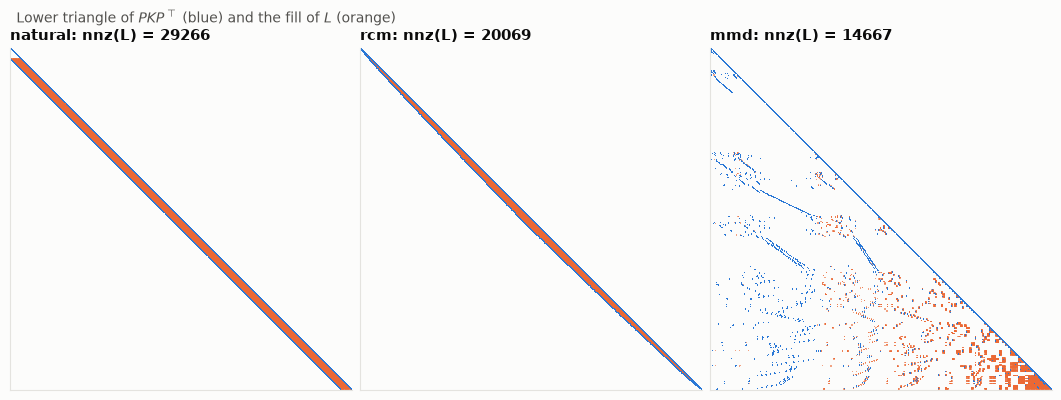

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.9))
for ax, (m, s) in zip(axes, analyses.items()):
  a_col = np.repeat(np.arange(s.n), np.diff(s.a_ptr))
  l_col = np.repeat(np.arange(s.n), np.diff(s.l_ptr))
  in_k = set(zip(s.a_rows.tolist(), a_col.tolist()))
  fill = np.array([(r, c) not in in_k for r, c in zip(s.l_rows.tolist(), l_col.tolist())])
  ax.plot(l_col[fill], s.l_rows[fill], ",", color=plotstyle.ORANGE, alpha=0.6)
  ax.plot(a_col, s.a_rows, ",", color=plotstyle.BLUE)
  ax.set_xlim(0, s.n)
  ax.set_ylim(s.n, 0)
  ax.set_aspect("equal")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_title(f"{m}: nnz(L) = {s.nnz_l}")
fig.suptitle(r"Lower triangle of $PKP^\top$ (blue) and the fill of $L$ (orange)", x=0.01, ha="left", fontsize=10, color=plotstyle.TEXT_SECONDARY)
plt.show()

The elimination tree has an edge from column $j$ to its parent, the first off-diagonal row of column
$j$ of $L$; column $j$ can be eliminated once its subtree is. Coloured by each node's depth in
that tree, drawn at the node of the plate each column eliminates, the reverse Cuthill–McKee tree is a
single chain sweeping across the plate. The minimum-degree tree is a sixth as tall: the columns
nearest its root form lines of nodes that cut the plate into pieces (separators, found greedily
rather than by nested dissection), and each piece is eliminated independently of the others.

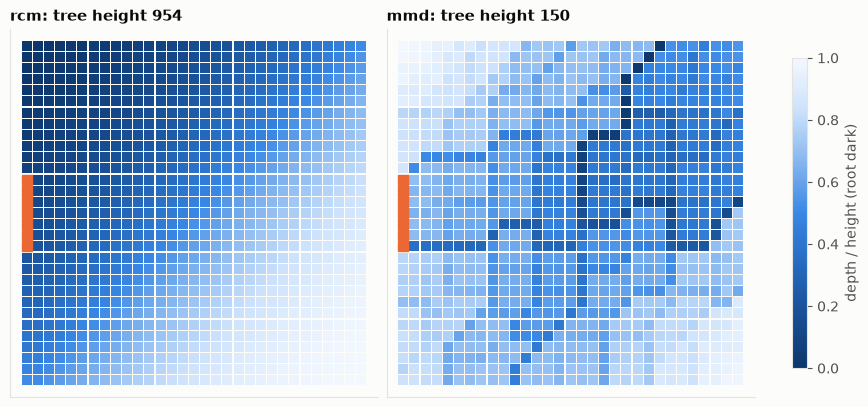

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.1))
for ax, m in zip(axes, ("rcm", "mmd")):
  s = analyses[m]
  depth = np.zeros(s.n)
  for j in s.postorder[::-1]:  # parents before children
    depth[j] = depth[s.parent[j]] + 1 if s.parent[j] >= 0 else 0
  where = XY[FREE[s.perm]]
  dots = ax.scatter(*where.T, c=depth / depth.max(), cmap=plotstyle.BLUES.reversed(), marker="s", s=52, linewidths=0)
  ax.plot(XY[SINK, 0], XY[SINK, 1], "s", color=plotstyle.ORANGE, ms=7)
  ax.set_aspect("equal")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_title(f"{m}: tree height {s.stats()['height']}")
fig.colorbar(dots, ax=axes, shrink=0.8, label="depth / height (root dark)")
plt.show()

The generated factorizations differ as the work does. Each ordering gives one `Function` (every
factorization in a graph needs its own `name`); the time is one call from Python: factor and solve.

In [12]:
def timed(fn, *args, repeat=200):
  fn(*args)  # compile
  best = np.inf
  for _ in range(5):
    start = time.perf_counter()
    for _ in range(repeat):
      fn(*args)
    best = min(best, (time.perf_counter() - start) / repeat)
  return best


for m, s in analyses.items():
  @sc.function(sc.S(K_PATTERN))
  def solve_with_ordering(K):
    return linalg.SparseLDL(K, ordering=m, name=f"plate_{m}").solve(sc.const(F_FREE))

  print(f"{m:8s} factor + solve {1e3 * timed(solve_with_ordering, K_num):6.3f} ms   (|T - T_scipy| = {np.abs(solve_with_ordering(K_num) - T_scipy[FREE]).max():.1e})")

natural  factor + solve  0.304 ms   (|T - T_scipy| = 5.6e-14)
rcm      factor + solve  0.197 ms   (|T - T_scipy| = 5.4e-14)
mmd      factor + solve  0.176 ms   (|T - T_scipy| = 4.0e-14)


## The adjoint gradient, for free

`compliance` chains the filter, the SIMP law, `conductance` and `temperature` symbolically, and asks
for `sc.gradient`. Reverse mode through `fact.solve` is one more solve with the same factor (the
compliance problem is self-adjoint, $\lambda = -T$), then the outer product on $K$'s pattern, back
through $R K R^\top$, the `segment_sum` of the assembly, the SIMP law and the filter. By hand,

$$
\frac{\partial c}{\partial \rho} = H^\top\!\left[ -3(1-k_{\min})\,\tilde\rho_e^{\,2}\; T_e^\top K_e T_e \right]_e .
$$

The density filter is a constant `SparseMatrix`: weights $\max(0, r - \lVert x_e - x_f\rVert)$ between
element centroids, normalized by row, as a SciPy matrix. `H @ rho` is a sparse matrix–vector product
in the generated code, and its transpose in the gradient.

In [13]:
K_MIN, PENALTY, VOLUME, R_FILTER = 1e-3, 3.0, 0.4, 2.0 * H_MESH
CENTROID = XY[TRIS].mean(axis=1)
pairs = cKDTree(CENTROID).query_pairs(R_FILTER, output_type="ndarray")
fi, fj = np.r_[pairs[:, 0], pairs[:, 1], np.arange(NE)], np.r_[pairs[:, 1], pairs[:, 0], np.arange(NE)]
H_scipy = sparse.csr_array((R_FILTER - np.linalg.norm(CENTROID[fi] - CENTROID[fj], axis=1), (fi, fj)), shape=(NE, NE))
H_scipy = sparse.csr_array(sparse.diags_array(1.0 / H_scipy.sum(axis=1)) @ H_scipy)
H_FILTER = sc.SparseMatrix.from_scipy(H_scipy)
print(f"filter: {H_FILTER.nnz} entries, {H_FILTER.nnz / NE:.1f} per element")


@sc.function(NE, output=sc.G("c", "dc"))
def compliance(rho):
  k = K_MIN + (1.0 - K_MIN) * (H_FILTER @ rho) ** PENALTY
  T = temperature(conductance(k))
  c = sc.dot(sc.const(F), T)
  return c, sc.gradient(c, rho)


rho0 = np.random.default_rng(1).uniform(0.2, 0.8, NE)
c0, dc0 = compliance(rho0)
filtered = H_scipy @ rho0
T0 = temperature(conductance(K_MIN + (1 - K_MIN) * filtered**PENALTY))
by_hand = H_scipy.T @ (-3 * (1 - K_MIN) * filtered**2 * np.einsum("ei,eij,ej->e", T0[TRIS], KE, T0[TRIS]))
direction = np.random.default_rng(2).standard_normal(NE)
eps = 1e-6
central = (compliance(rho0 + eps * direction)[0] - compliance(rho0 - eps * direction)[0]) / (2 * eps)
print(f"gradient vs the adjoint formula: relative error {np.abs(dc0 - by_hand).max() / np.abs(by_hand).max():.1e}")
print(f"directional derivative {dc0 @ direction:.10f} vs central difference {central:.10f}")

filter: 41124 entries, 22.8 per element
gradient vs the adjoint formula: relative error 1.3e-14
directional derivative 3.2651600102 vs central difference 3.2651600996


## The optimization

The optimality-criteria update multiplies each density by $\sqrt{-\partial_{\rho_e} c / (\lambda\,
\partial_{\rho_e} V)}$, clipped to a move limit of 0.2 and to $[0, 1]$, with the multiplier $\lambda$
found by bisection on the volume constraint. 80 iterations, each one call of `compliance`:

In [14]:
dv = H_scipy.T @ (AREA / AREA.sum())
rho = np.full(NE, VOLUME)
history, calls = [], 0.0
for iteration in range(80):
  start = time.perf_counter()
  c, dc = compliance(rho)
  calls += time.perf_counter() - start
  history.append(float(c))
  lo, hi = 1e-9, 1e9
  while hi / lo > 1 + 1e-9:
    lam = np.sqrt(lo * hi)
    candidate = np.clip(rho * np.sqrt(np.maximum(-dc, 0.0) / (lam * dv)), np.maximum(0.0, rho - 0.2), np.minimum(1.0, rho + 0.2))
    lo, hi = (lam, hi) if AREA @ (H_scipy @ candidate) / AREA.sum() > VOLUME else (lo, lam)
  change, rho = np.abs(candidate - rho).max(), candidate
print(f"compliance {history[0]:.3f} (uniform) -> {history[-1]:.3f}; last change {change:.3f}; volume {AREA @ (H_scipy @ rho) / AREA.sum():.3f}")
print(f"{1e3 * calls / len(history):.2f} ms per compliance-and-gradient call")

compliance 10.356 (uniform) -> 1.621; last change 0.037; volume 0.400
0.63 ms per compliance-and-gradient call


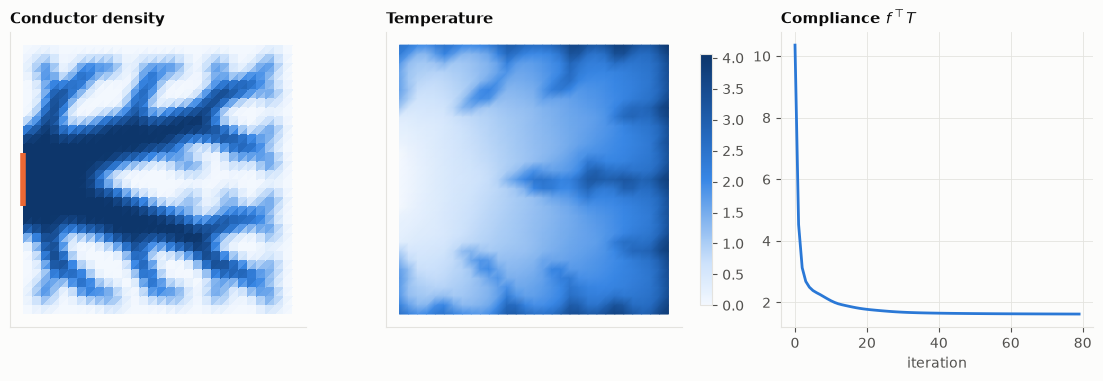

In [15]:
design = H_scipy @ rho
T_final = temperature(conductance(K_MIN + (1 - K_MIN) * design**PENALTY))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3.7), gridspec_kw={"width_ratios": [1, 1.15, 1]})
ax1.tripcolor(XY[:, 0], XY[:, 1], TRIS, facecolors=design, cmap=plotstyle.BLUES, vmin=0, vmax=1)
ax1.plot(XY[SINK, 0], XY[SINK, 1], color=plotstyle.ORANGE, lw=4, solid_capstyle="butt")
ax1.set_title("Conductor density")
image = ax2.tripcolor(XY[:, 0], XY[:, 1], TRIS, T_final, shading="gouraud", cmap=plotstyle.BLUES)
fig.colorbar(image, ax=ax2, shrink=0.85)
ax2.set_title("Temperature")
for ax in (ax1, ax2):
  ax.set_aspect("equal")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
ax3.plot(history, color=plotstyle.BLUE)
ax3.set_xlabel("iteration")
ax3.set_title(r"Compliance $f^\top T$")
plt.show()

The sink (orange) feeds a trunk that branches as it reaches into the plate, the classic
volume-to-point tree. A finer mesh gives finer branches; the filter radius, not the mesh, sets
their thickness.

## The generated C

`compliance` is one C function: the filter product, the assembly, the restriction, the sparse
$LDL^\top$ with its minimum-degree tables, the solve and the whole reverse sweep.

In [16]:
module = write_module(compliance, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

compliance.c: 620 lines, 5093 kB, workspace 200350 doubles


## References

- A. Bejan, "Constructal-theory network of conducting paths for cooling a heat generating volume,"
  *International Journal of Heat and Mass Transfer* 40 (1997), 799–816.
  [doi:10.1016/0017-9310(96)00175-5](https://doi.org/10.1016/0017-9310(96)00175-5)
- O. Sigmund, "A 99 line topology optimization code written in Matlab," *Structural and
  Multidisciplinary Optimization* 21 (2001), 120–127. [doi:10.1007/s001580050176](https://doi.org/10.1007/s001580050176)
- T. A. Davis, *Direct Methods for Sparse Linear Systems*, SIAM (2006), chapters 4 and 7 (elimination
  trees, orderings). [doi:10.1137/1.9780898718881](https://doi.org/10.1137/1.9780898718881)